torch.Size([1, 9689966])
torch.Size([12, 18926])
(12, 18926)
Torchaudio-Librosa Similarity 0.3179
Normalized Torchaudio-Librosa Similarity 0.9977


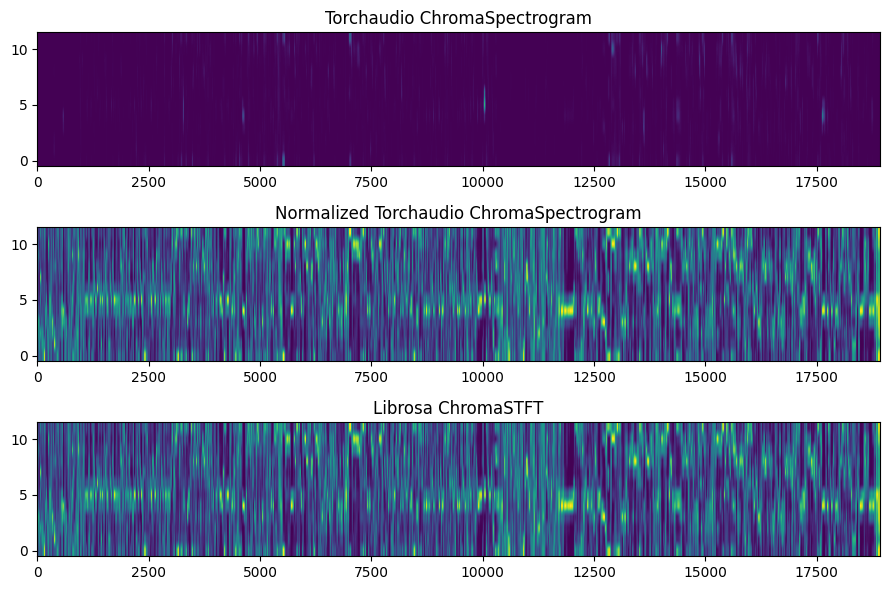

In [29]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchaudio
from torchaudio.prototype.transforms import ChromaSpectrogram

sr = 16000
n_fft = 2048
hop_length = 512
audio_file = "/Users/jcastle/workspace/pansori/opt/data/Audio/30c011be-01-박초월-수궁가_별주부_토끼_유인하는_대목.wav"

audio, osr = torchaudio.load(audio_file)
audio = torchaudio.functional.resample(audio, orig_freq=osr, new_freq=sr).mean(dim=0, keepdim=True)
print(audio.shape)


cs = ChromaSpectrogram(sample_rate=sr, n_fft=n_fft, hop_length=hop_length,window_fn=torch.hann_window,power=2.0,  normalized=False)
tc_raw = cs(audio).squeeze(0)
print(tc_raw.shape)

plt.figure(figsize=(9,6))

plt.subplot(3,1,1)
plt.imshow(tc_raw, origin='lower', aspect='auto')
plt.title("Torchaudio ChromaSpectrogram")

def normalize_like_librosa(chroma):
    """
    librosa.util.normalize와 유사한 방식으로 정규화
    norm=np.inf: 각 프레임(열)의 최대값을 1로 정규화
    """
    # 각 열(프레임)의 최대값으로 나누기
    max_values, _ = torch.max(chroma, dim=0, keepdim=True)
    # 0으로 나누기 방지
    max_values[max_values == 0] = 1.0
    return chroma / max_values

tc_normalized = normalize_like_librosa(tc_raw)

plt.subplot(3,1,2)
plt.imshow(tc_normalized, origin='lower', aspect='auto')
plt.title("Normalized Torchaudio ChromaSpectrogram")

lc = librosa.feature.chroma_stft(y=audio.squeeze(0).numpy(), sr=sr, hop_length=hop_length)
print(lc.shape)
plt.subplot(3,1,3)
plt.imshow(lc, origin='lower', aspect='auto')
plt.title("Librosa ChromaSTFT")

sim = np.corrcoef(tc_raw.numpy().flatten(), lc.flatten())[0,1]
print(f"Torchaudio-Librosa Similarity {sim:.4f}")

sim = np.corrcoef(tc_normalized.numpy().flatten(), lc.flatten())[0,1]
print(f"Normalized Torchaudio-Librosa Similarity {sim:.4f}")

plt.tight_layout()

In [380]:
from datasets import AudioDataset

import random

from tqdm import tqdm

import torchaudio
from torchaudio.prototype.transforms import ChromaSpectrogram

In [381]:
class ChromaDataset(AudioDataset):
    def __init__(self, audio_dir, label_json, num_classes=4, sr=16000, channels='mono', window=20, n_fft=2048, hop_length=512, target_bins=25):
        super().__init__(audio_dir, label_json, num_classes, sr, channels, window)
        self.hop_length = hop_length
        self.target_bins = target_bins
        self.window_frame = self.window * sr // hop_length
        self.chroma_cvt = ChromaSpectrogram(sample_rate=self.sr, n_fft=n_fft, hop_length=hop_length)
        self.loaded_chromas = self.get_chroma()


    def get_chroma(self):
        chroma_dict = {}
        for k, v in tqdm(self.loaded_audio.items(), desc='Load Chromagram'):
            chroma = self.chroma_cvt(v).squeeze(0)
            # librosa 구현형
            max_values, _ = torch.max(chroma, dim=0, keepdim=True)
            max_values[max_values == 0] = 1.0 # 최댓값이 0인 경우 => 1
            chroma = chroma / max_values # 가장 강한 음높이 성분 => 1
            # expand chroma
            repeat = self.target_bins // chroma.shape[0] + 1
            expanded_chroma = chroma.repeat_interleave(repeat, dim=0)
            
            chroma_dict[k] = expanded_chroma[:self.target_bins, :]
        return chroma_dict

    def get_label(self, filename, start):
        labels = torch.zeros((self.window_frame, self.num_classes))
        label_ant = self.label_dict[filename]

        duration = self.loaded_audio[filename].shape[1]/self.sr
        num_frames = self.loaded_chromas[filename].shape[1]

        for frame_idx in range(self.window_frame):
            start_frame = start + frame_idx
            end_frame = start_frame+ 1

            overlap_ratios = {'Unknown': 1.0}

            for ant in label_ant:
                label_name = ant['label']

                start_ant, end_ant = ant['start'], ant['end'] # sec
                start_ant, end_ant = int(num_frames * start_ant / duration), int(num_frames * end_ant / duration) # frame

                if end_ant <= start_frame or start_ant >= end_frame: continue

                overlap_start = max(start_frame, start_ant)
                overlap_end = min(end_frame, end_ant)
                overlap_duration = overlap_end - overlap_start
                
                if overlap_duration > 0:
                    if label_name not in overlap_ratios: overlap_ratios[label_name] = 0.0
                    
                    overlap_ratios[label_name] += overlap_duration
                    overlap_ratios['Unknown'] -= overlap_duration
            
            overlap_ratios['Unknown'] = max(0, overlap_ratios['Unknown'])
            max_label = max(overlap_ratios, key=overlap_ratios.get)
            
            if max_label == 'Unknown': labels[frame_idx, self.label_map['Unknown']] = 1
            else: labels[frame_idx, self.label_map[max_label]] = 1

        return labels


    def get_start_time(self, filename, start_frame):
        return start_frame*(self.loaded_audio[filename].shape[1]/self.sr)/self.loaded_chromas[filename].shape[1]

    def __getitem__(self, idx):
        filename = self.loaded_filename[idx]
        chroma, label = self.loaded_chromas[filename], self.label_dict[filename]

        if self.window:
            start_frame = random.randint(0, chroma.shape[1] - self.window_frame)
            chroma = chroma[:, start_frame:start_frame+self.window_frame]
            label = self.get_label(filename, start_frame)
            return chroma, label, (filename, start_frame)

        return chroma, label


In [382]:
audio_dir = "/Users/jcastle/workspace/pansori/opt/data/Audio"
label_json = "/Users/jcastle/workspace/pansori/opt/data/label.json"
dset = ChromaDataset(audio_dir, label_json)

Load Audio: 18it [00:06,  2.81it/s]
Load Chromagram: 100%|██████████| 18/18 [00:01<00:00, 10.25it/s]


In [386]:
chroma, label, meta = dset[5]
filename, start_frame = meta
start_time = dset.get_start_time(filename, start_frame)

print(chroma.shape)
print(label.shape)
print(filename)
print(start_frame, start_time)

torch.Size([25, 625])
torch.Size([625, 4])
08-성우향-춘향가_이도령이_천자뒤풀이를_하는_데
11644 372.5899072996562


In [369]:
dset.label_dict[filename]

[{'start': 0, 'end': 20.614, 'label': '아니리'},
 {'start': 69.8180433543733, 'end': 133.0906451442741, 'label': '아니리'},
 {'start': 133.52700791523895, 'end': 243.92678896934174, 'label': '우조'},
 {'start': 244.71065638455718, 'end': 248.74032288190762, 'label': '계면조'},
 {'start': 249.8393228357305, 'end': 278.41332163512493, 'label': '우조'},
 {'start': 279.1459882710068, 'end': 319.8089865624527, 'label': '계면조'},
 {'start': 320.7704950038168, 'end': 340.472329629771, 'label': '우조'},
 {'start': 340.68998568508704, 'end': 349.84831863361086, 'label': '계면조'},
 {'start': 350.21465195155184, 'end': 357.9076516283119, 'label': '우조'},
 {'start': 358.2739849462528, 'end': 367.43231789477665, 'label': '계면조'},
 {'start': 367.43231789477665, 'end': 402.9666497350492, 'label': '우조'},
 {'start': 403.6993163709311, 'end': 412.85764931945494, 'label': '계면조'}]

08-성우향-춘향가_이도령이_천자뒤풀이를_하는_데
11078 354.47878676276116
354.47878676276116


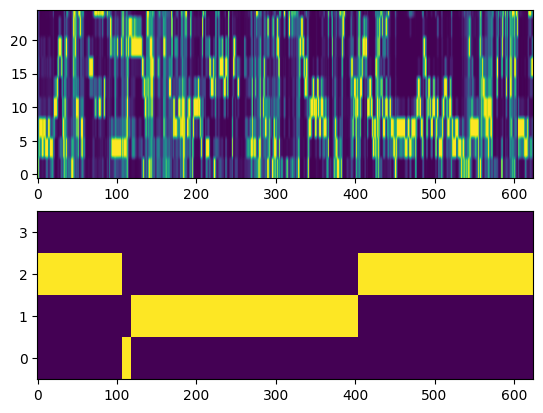

In [370]:
plt.subplot(2,1,1)
plt.imshow(chroma, aspect='auto', origin='lower')

plt.subplot(2,1,2)
plt.imshow(label.T, aspect='auto', origin='lower', interpolation='None')

print(filename)
print(start_frame, start_time)

import IPython.display as ipd

audio = dset.loaded_audio[filename]
start = int(start_time * dset.sr)
segment = audio[0, start:start+dset.window*dset.sr]
print(start_time)
ipd.display(ipd.Audio(data=segment, rate=dset.sr))


In [379]:
l = label.argmax(dim=1)
i = torch.where(l == 0)[0]

dset.get_start_time(filename, start_frame+i[0]), dset.get_start_time(filename, start_frame+i[-1])

(tensor(357.9026), tensor(358.2226))